In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
loans_info = pd.read_csv('../DATA/lending_club_info.csv',index_col='LoanStatNew')

In [3]:
loans_info.keys

<bound method NDFrame.keys of                                                             Description
LoanStatNew                                                            
loan_amnt             The listed amount of the loan applied for by t...
term                  The number of payments on the loan. Values are...
int_rate                                      Interest Rate on the loan
installment           The monthly payment owed by the borrower if th...
grade                                            LC assigned loan grade
sub_grade                                     LC assigned loan subgrade
emp_title             The job title supplied by the Borrower when ap...
emp_length            Employment length in years. Possible values ar...
home_ownership        The home ownership status provided by the borr...
annual_inc            The self-reported annual income provided by th...
verification_status   Indicates if income was verified by LC, not ve...
issue_d                           

In [4]:
def feat_info(col_name):
    print(loans_info.loc[col_name]['Description'])

In [25]:
feat_info('total_acc')

The total number of credit lines currently in the borrower's credit file


In [23]:
loans_info

,Description
LoanStatNew,
loan_amnt,The listed amount of the loan applied for by t...
term,The number of payments on the loan. Values are...
int_rate,Interest Rate on the loan
installment,The monthly payment owed by the borrower if th...
grade,LC assigned loan grade
sub_grade,LC assigned loan subgrade
emp_title,The job title supplied by the Borrower when ap...
emp_length,Employment length in years. Possible values ar...
home_ownership,The home ownership status provided by the borr...


In [5]:
loans = pd.read_csv('../DATA/lending_club_loan_two.csv')

In [6]:
loans.iloc[1]

loan_amnt                                                        8000.0
term                                                          36 months
int_rate                                                          11.99
installment                                                      265.68
grade                                                                 B
sub_grade                                                            B5
emp_title                                               Credit analyst 
emp_length                                                      4 years
home_ownership                                                 MORTGAGE
annual_inc                                                      65000.0
verification_status                                        Not Verified
issue_d                                                        Jan-2015
loan_status                                                  Fully Paid
purpose                                              debt_consol

In [7]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [8]:
loans.drop('loan_status',axis=1).head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


# Feature Engineering

In [9]:
loans['term'].iloc[1]

' 36 months'

In [10]:
# the term value contains the duration of the loan , lets extract it from an object to an interger value
term = loans['term'].apply(lambda x : (x.lstrip().split()[0])).astype('int32')

<Axes: >

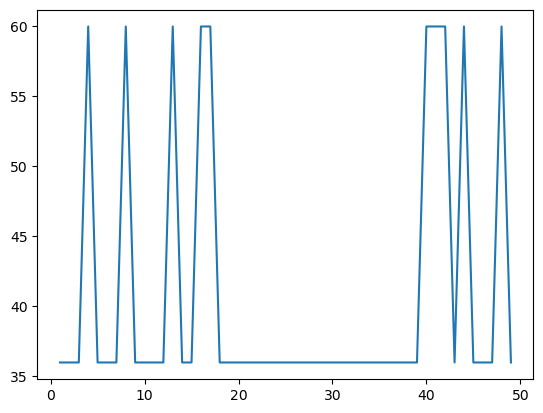

In [11]:
term[1:50].plot()

In [12]:
term

0         36
1         36
2         36
3         36
4         60
          ..
396025    60
396026    36
396027    36
396028    60
396029    36
Name: term, Length: 396030, dtype: int32

In [13]:
loans['term'] = loans['term'].apply(lambda x : (x.lstrip().split()[0])).astype('int32')

In [14]:
loans

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\nJohnnyville, DC 30723"
396026,21000.0,36,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\nRachelborough, LA..."
396027,5000.0,36,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\nReedfort, NY 70466"
396028,21000.0,60,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\nNew Michael, FL 2..."


In [15]:
loans['grade'].value_counts()

grade
B    116018
C    105987
A     64187
D     63524
E     31488
F     11772
G      3054
Name: count, dtype: int64

In [16]:
# hot encoding the grade coloumn for classification of grade
from sklearn.preprocessing import OneHotEncoder

In [17]:
encoder = OneHotEncoder(sparse_output=False)

In [18]:
grade = pd.get_dummies(loans['grade'],dtype='int32')
grade

,A,B,C,D,E,F,G
0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0
3,1,0,0,0,0,0,0
4,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...
396025,0,1,0,0,0,0,0
396026,0,0,1,0,0,0,0
396027,0,1,0,0,0,0,0
396028,0,0,1,0,0,0,0


In [19]:
loans = pd.concat([loans,grade],axis=1)

In [20]:
loans

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,mort_acc,pub_rec_bankruptcies,address,A,B,C,D,E,F,G
0,10000.0,36,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",0,1,0,0,0,0,0
1,8000.0,36,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",0,1,0,0,0,0,0
2,15600.0,36,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",0,1,0,0,0,0,0
3,7200.0,36,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1,0,0,0,0,0,0
4,24375.0,60,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,0.0,0.0,"12951 Williams Crossing\nJohnnyville, DC 30723",0,1,0,0,0,0,0
396026,21000.0,36,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,1.0,0.0,"0114 Fowler Field Suite 028\nRachelborough, LA...",0,0,1,0,0,0,0
396027,5000.0,36,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,0.0,0.0,"953 Matthew Points Suite 414\nReedfort, NY 70466",0,1,0,0,0,0,0
396028,21000.0,60,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,5.0,0.0,"7843 Blake Freeway Apt. 229\nNew Michael, FL 2...",0,0,1,0,0,0,0


<Axes: >

<Figure size 2000x12000 with 0 Axes>

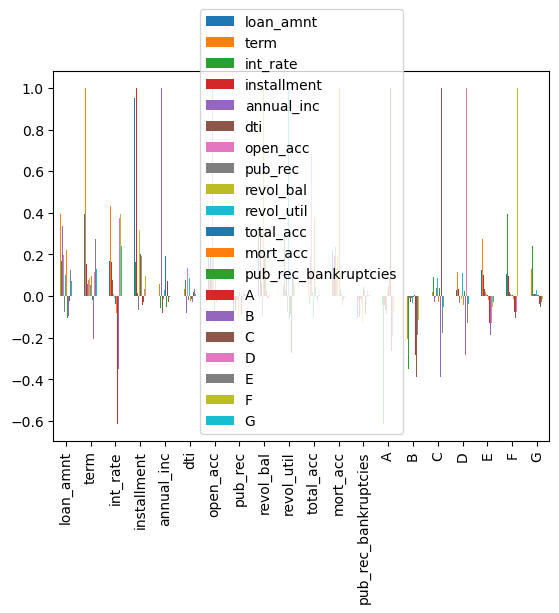

In [21]:
plt.figure(figsize=(20,120))

loans.corr(numeric_only=True).plot(kind='bar')

In [22]:
loans['loan_status'].value_counts()

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

In [23]:
loan_status = pd.get_dummies(loans['loan_status'],dtype='int32',drop_first=True)

In [24]:
loans['loan_status']= loan_status

In [25]:
corr = loans.corr(numeric_only=True)

In [109]:
# we can drop grade , subgrade since grade is one hot encoded adn subgrade is tmi , also address becausde it doesnt seem necessary

In [26]:
corr[corr<0.1]

,loan_amnt,term,int_rate,installment,annual_inc,loan_status,dti,open_acc,pub_rec,revol_bal,...,total_acc,mort_acc,pub_rec_bankruptcies,A,B,C,D,E,F,G
loan_amnt,NaN,NaN,NaN,NaN,NaN,-0.059836,0.016636,NaN,-0.077779,NaN,...,NaN,NaN,-0.106539,-0.043107,-0.093824,-0.025500,0.030413,NaN,NaN,0.071370
term,NaN,NaN,NaN,NaN,0.060330,-0.173246,0.036508,0.079575,-0.018758,0.084787,...,NaN,0.096220,-0.019826,-0.222049,-0.206173,0.019244,NaN,NaN,NaN,NaN
int_rate,NaN,NaN,NaN,NaN,-0.056771,-0.247758,0.079038,0.011649,0.060986,-0.011280,...,-0.036404,-0.082583,0.057450,-0.614300,-0.347779,0.091725,NaN,NaN,NaN,NaN
installment,NaN,NaN,NaN,NaN,NaN,-0.041082,0.015786,NaN,-0.067892,NaN,...,NaN,NaN,-0.098628,-0.041618,-0.077211,-0.029885,0.034869,NaN,0.097539,0.073385
annual_inc,NaN,0.060330,-0.056771,NaN,NaN,0.053432,-0.081685,NaN,-0.013720,NaN,...,NaN,NaN,-0.050162,0.074923,-0.007106,-0.029209,-0.032065,-0.003111,0.002286,0.008865
loan_status,-0.059836,-0.173246,-0.247758,-0.041082,0.053432,NaN,-0.062413,-0.028012,-0.019933,0.010892,...,0.017893,0.073111,-0.009383,NaN,NaN,-0.023871,-0.101877,-0.131385,-0.102158,-0.062667
dti,0.016636,0.036508,0.079038,0.015786,-0.081685,-0.062413,NaN,NaN,-0.017639,0.063571,...,NaN,-0.025439,-0.014558,-0.064815,-0.025969,0.021868,0.033991,0.034338,0.020359,0.009170
open_acc,NaN,0.079575,0.011649,NaN,NaN,-0.028012,NaN,NaN,-0.018392,NaN,...,NaN,NaN,-0.027732,0.009144,-0.021020,-0.006180,-0.000089,0.019045,0.015203,0.014078
pub_rec,-0.077779,-0.018758,0.060986,-0.067892,-0.013720,-0.019933,-0.017639,-0.018392,NaN,-0.101664,...,0.019723,0.011552,NaN,-0.083946,-0.006977,0.038284,0.029272,0.014917,0.009788,0.008257
revol_bal,NaN,0.084787,-0.011280,NaN,NaN,0.010892,0.063571,NaN,-0.101664,NaN,...,NaN,NaN,-0.124532,0.023403,-0.005504,-0.009692,-0.014687,0.009199,0.003870,0.004751


In [27]:
loans['emp_title'].value_counts()

emp_title
Teacher                    4389
Manager                    4250
Registered Nurse           1856
RN                         1846
Supervisor                 1830
                           ... 
Postman                       1
McCarthy & Holthus, LLC       1
jp flooring                   1
Histology Technologist        1
Gracon Services, Inc          1
Name: count, Length: 173105, dtype: int64

In [118]:
# emp title has too many categories to differentitatte between , hence dropping them may be a good idea for right now

In [28]:
loans['emp_length']= loans['emp_length'].apply(
    lambda x: 10 if isinstance(x, str) and '10+' in x else
              (0.5 if isinstance(x, str) and '< 1' in x else 
              (int(x.split()[0]) if isinstance(x, str) else np.nan))
) #this is to convert all the emp length to a readable year count

In [29]:
loans

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,mort_acc,pub_rec_bankruptcies,address,A,B,C,D,E,F,G
0,10000.0,36,11.44,329.48,B,B4,Marketing,10.0,RENT,117000.0,...,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",0,1,0,0,0,0,0
1,8000.0,36,11.99,265.68,B,B5,Credit analyst,4.0,MORTGAGE,65000.0,...,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",0,1,0,0,0,0,0
2,15600.0,36,10.49,506.97,B,B3,Statistician,0.5,RENT,43057.0,...,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",0,1,0,0,0,0,0
3,7200.0,36,6.49,220.65,A,A2,Client Advocate,6.0,RENT,54000.0,...,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1,0,0,0,0,0,0
4,24375.0,60,17.27,609.33,C,C5,Destiny Management Inc.,9.0,MORTGAGE,55000.0,...,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60,10.99,217.38,B,B4,licensed bankere,2.0,RENT,40000.0,...,0.0,0.0,"12951 Williams Crossing\nJohnnyville, DC 30723",0,1,0,0,0,0,0
396026,21000.0,36,12.29,700.42,C,C1,Agent,5.0,MORTGAGE,110000.0,...,1.0,0.0,"0114 Fowler Field Suite 028\nRachelborough, LA...",0,0,1,0,0,0,0
396027,5000.0,36,9.99,161.32,B,B1,City Carrier,10.0,RENT,56500.0,...,0.0,0.0,"953 Matthew Points Suite 414\nReedfort, NY 70466",0,1,0,0,0,0,0
396028,21000.0,60,15.31,503.02,C,C2,"Gracon Services, Inc",10.0,MORTGAGE,64000.0,...,5.0,0.0,"7843 Blake Freeway Apt. 229\nNew Michael, FL 2...",0,0,1,0,0,0,0


In [30]:
loans.drop(['grade','sub_grade','emp_title','address'],axis=1) #inplace true is not done yet

,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,...,application_type,mort_acc,pub_rec_bankruptcies,A,B,C,D,E,F,G
0,10000.0,36,11.44,329.48,10.0,RENT,117000.0,Not Verified,Jan-2015,1,...,INDIVIDUAL,0.0,0.0,0,1,0,0,0,0,0
1,8000.0,36,11.99,265.68,4.0,MORTGAGE,65000.0,Not Verified,Jan-2015,1,...,INDIVIDUAL,3.0,0.0,0,1,0,0,0,0,0
2,15600.0,36,10.49,506.97,0.5,RENT,43057.0,Source Verified,Jan-2015,1,...,INDIVIDUAL,0.0,0.0,0,1,0,0,0,0,0
3,7200.0,36,6.49,220.65,6.0,RENT,54000.0,Not Verified,Nov-2014,1,...,INDIVIDUAL,0.0,0.0,1,0,0,0,0,0,0
4,24375.0,60,17.27,609.33,9.0,MORTGAGE,55000.0,Verified,Apr-2013,0,...,INDIVIDUAL,1.0,0.0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60,10.99,217.38,2.0,RENT,40000.0,Source Verified,Oct-2015,1,...,INDIVIDUAL,0.0,0.0,0,1,0,0,0,0,0
396026,21000.0,36,12.29,700.42,5.0,MORTGAGE,110000.0,Source Verified,Feb-2015,1,...,INDIVIDUAL,1.0,0.0,0,0,1,0,0,0,0
396027,5000.0,36,9.99,161.32,10.0,RENT,56500.0,Verified,Oct-2013,1,...,INDIVIDUAL,0.0,0.0,0,1,0,0,0,0,0
396028,21000.0,60,15.31,503.02,10.0,MORTGAGE,64000.0,Verified,Aug-2012,1,...,INDIVIDUAL,5.0,0.0,0,0,1,0,0,0,0


In [31]:
ownership = loans['home_ownership'].apply(lambda x : 1 if x == 'OWN' else 0)

In [32]:
ownership.value_counts()

home_ownership
0    358284
1     37746
Name: count, dtype: int64

In [33]:
loans['home_ownership']= ownership  # 1 if owned 0 if rent , mortgage, etc 

In [34]:
loans

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,mort_acc,pub_rec_bankruptcies,address,A,B,C,D,E,F,G
0,10000.0,36,11.44,329.48,B,B4,Marketing,10.0,0,117000.0,...,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",0,1,0,0,0,0,0
1,8000.0,36,11.99,265.68,B,B5,Credit analyst,4.0,0,65000.0,...,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",0,1,0,0,0,0,0
2,15600.0,36,10.49,506.97,B,B3,Statistician,0.5,0,43057.0,...,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",0,1,0,0,0,0,0
3,7200.0,36,6.49,220.65,A,A2,Client Advocate,6.0,0,54000.0,...,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1,0,0,0,0,0,0
4,24375.0,60,17.27,609.33,C,C5,Destiny Management Inc.,9.0,0,55000.0,...,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60,10.99,217.38,B,B4,licensed bankere,2.0,0,40000.0,...,0.0,0.0,"12951 Williams Crossing\nJohnnyville, DC 30723",0,1,0,0,0,0,0
396026,21000.0,36,12.29,700.42,C,C1,Agent,5.0,0,110000.0,...,1.0,0.0,"0114 Fowler Field Suite 028\nRachelborough, LA...",0,0,1,0,0,0,0
396027,5000.0,36,9.99,161.32,B,B1,City Carrier,10.0,0,56500.0,...,0.0,0.0,"953 Matthew Points Suite 414\nReedfort, NY 70466",0,1,0,0,0,0,0
396028,21000.0,60,15.31,503.02,C,C2,"Gracon Services, Inc",10.0,0,64000.0,...,5.0,0.0,"7843 Blake Freeway Apt. 229\nNew Michael, FL 2...",0,0,1,0,0,0,0


In [67]:
loans['verification_status'].value_counts()

verification_status
Verified           139563
Source Verified    131385
Not Verified       125082
Name: count, dtype: int64

In [68]:
feat_info('verification_status')

Indicates if income was verified by LC, not verified, or if the income source was verified


In [69]:
verification = loans['verification_status'].apply(lambda x : 0 if x == 'Not Verified' else 1)

In [70]:
verification.value_counts()

verification_status
1    270948
0    125082
Name: count, dtype: int64

In [71]:
loans['verification_status'] = verification

In [72]:
loans['verification_status']

0         0
1         0
2         1
3         0
4         1
         ..
396025    1
396026    1
396027    1
396028    1
396029    1
Name: verification_status, Length: 396030, dtype: int64

In [39]:
loans['purpose'].value_counts()

purpose
debt_consolidation    234507
credit_card            83019
home_improvement       24030
other                  21185
major_purchase          8790
small_business          5701
car                     4697
medical                 4196
moving                  2854
vacation                2452
house                   2201
wedding                 1812
renewable_energy         329
educational              257
Name: count, dtype: int64

<Axes: xlabel='purpose', ylabel='count'>

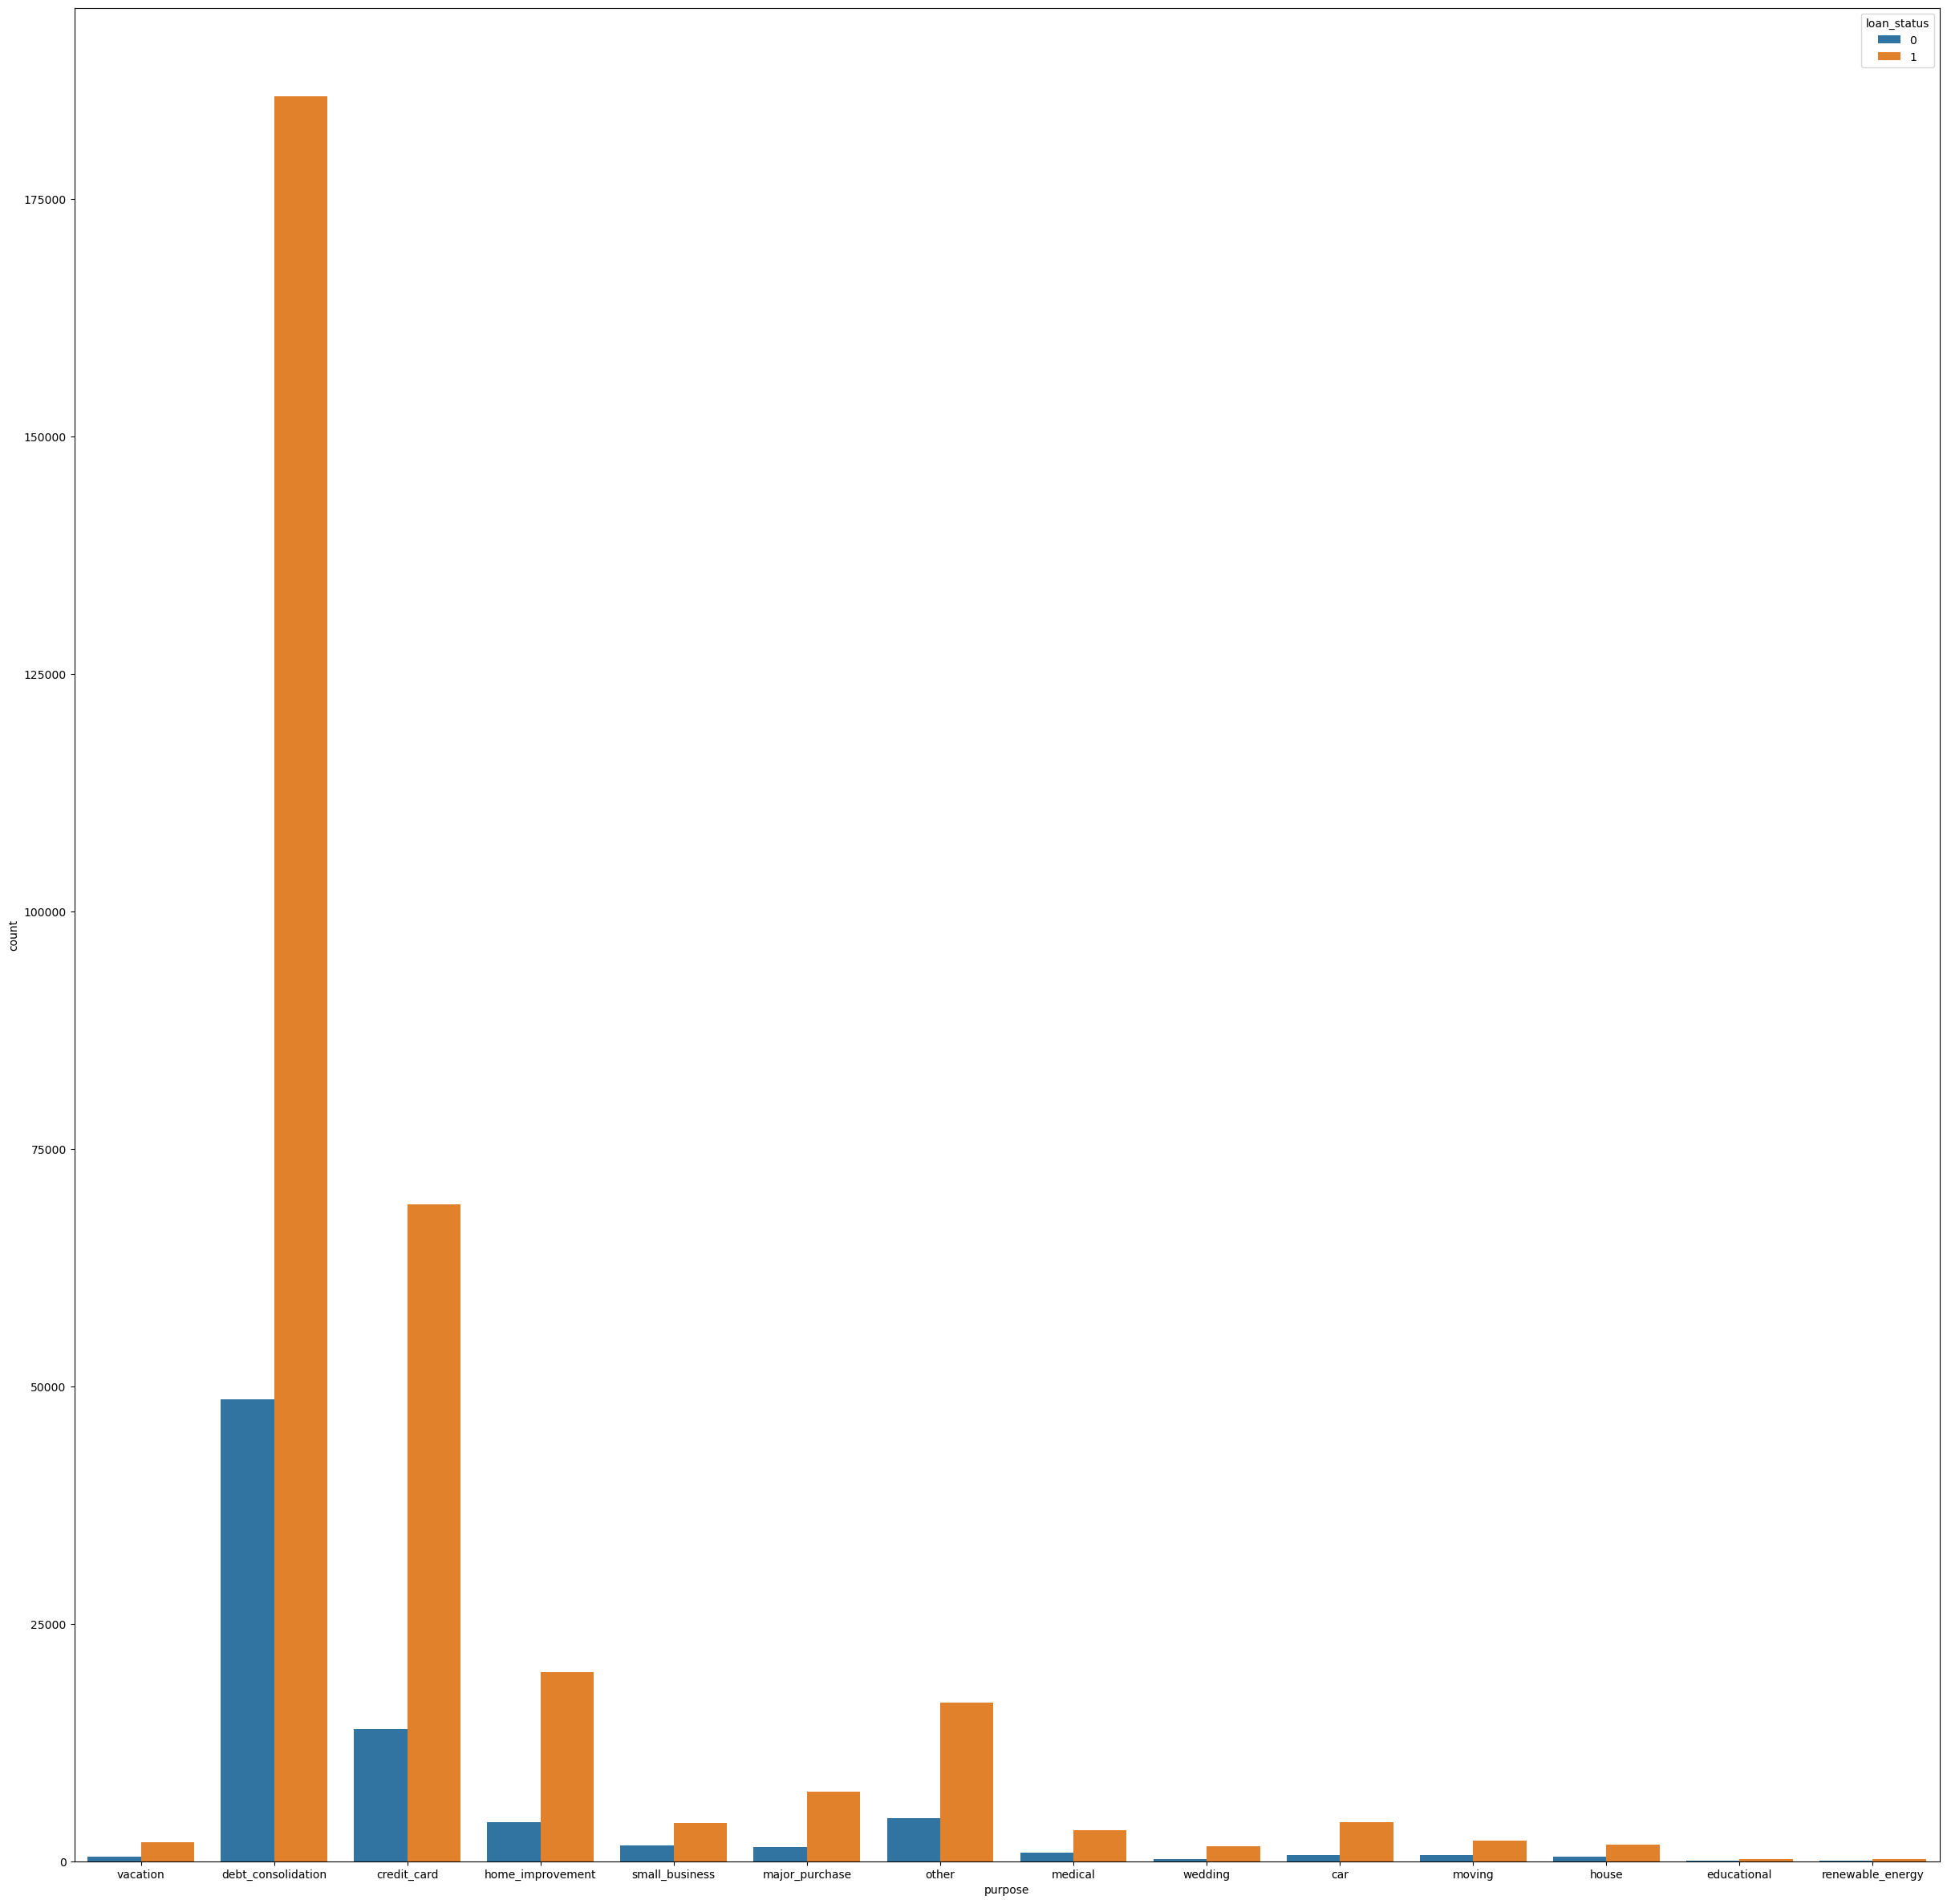

In [165]:
plt.figure(figsize=(30,30))
sns.countplot(data=loans,x='purpose',hue='loan_status')

In [41]:
purpose

,car,credit_card,debt_consolidation,educational,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation,wedding
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,False,False,True,False,False,False,False,False,False,False,False,False,False,False
396026,False,False,True,False,False,False,False,False,False,False,False,False,False,False
396027,False,False,True,False,False,False,False,False,False,False,False,False,False,False
396028,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [170]:
from sklearn.preprocessing import LabelEncoder

In [184]:
# One-hot encoding the 'purpose' co
purpose = pd.get_dummies(loans['purpose'])


In [185]:
le = LabelEncoder()

In [187]:
purpose['purpose_encoded'] = le.fit_transform(purpose)

ValueError: y should be a 1d array, got an array of shape (396030, 14) instead.

In [175]:
purpose

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [42]:
#label encoding wont work since it is used to encode target variables so lets try Ordinal Encoding to categorize the purpose into integers

In [43]:
from sklearn.preprocessing import OrdinalEncoder

In [44]:
encoder = OrdinalEncoder()

In [46]:
purpose = encoder.fit_transform(loans[['purpose']])

In [48]:
purpose # this reduces the dimensionality , also we will keep this for the entire dataset to help with the validation data aswell

array([[12.],
       [ 2.],
       [ 1.],
       ...,
       [ 2.],
       [ 2.],
       [ 2.]])

In [49]:
loans['purpose']=purpose

In [53]:
loans['purpose'].head(20)

0     12.0
1      2.0
2      1.0
3      1.0
4      1.0
5      2.0
6      4.0
7      1.0
8      2.0
9      2.0
10     2.0
11     1.0
12     2.0
13     2.0
14    11.0
15     6.0
16     2.0
17     2.0
18     2.0
19     2.0
Name: purpose, dtype: float64

In [77]:
loans.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  int32  
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  float64
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  float64
 8   home_ownership        396030 non-null  int64  
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  int64  
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  int32  
 13  purpose               396030 non-null  float64
 14  title                 394274 non-null  object 
 15  

In [55]:
# we can apply the same logic for the grade aswell to further reduce dimensionality 

In [58]:
grades = encoder.fit_transform(loans[['grade']])

In [60]:
loans['grade']= grades

In [63]:
loans['grade'].head(10)

0    1.0
1    1.0
2    1.0
3    0.0
4    2.0
5    2.0
6    0.0
7    1.0
8    1.0
9    2.0
Name: grade, dtype: float64

In [64]:
loans.drop(['A','B','C','D','E','F','G'],axis=1,inplace=True)

In [74]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  int32  
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  float64
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  float64
 8   home_ownership        396030 non-null  int64  
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  int64  
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  int32  
 13  purpose               396030 non-null  float64
 14  title                 394274 non-null  object 
 15  

In [73]:
loans['verification_status'].head(10)

0    0
1    0
2    1
3    0
4    1
5    1
6    1
7    0
8    1
9    1
Name: verification_status, dtype: int64

In [78]:
feat_info('title')

The loan title provided by the borrower


In [81]:
loans['title'].head(10) # this is closely similar to purpose and hence we can possibly drop this 

0                   Vacation
1         Debt consolidation
2    Credit card refinancing
3    Credit card refinancing
4      Credit Card Refinance
5         Debt consolidation
6           Home improvement
7       No More Credit Cards
8         Debt consolidation
9         Debt Consolidation
Name: title, dtype: object

In [92]:
feat_info('initial_list_status') #without any relevant domain knowlegde this information would not be of any good use 

The initial listing status of the loan. Possible values are – W, F


In [93]:
# this marks the end of my feature engineering from the data provided 
## the next step is dropping irrelvant coloumns and preprocessing and scaling the features

In [94]:
final_data = loans.drop(['sub_grade','emp_title','issue_d','title','earliest_cr_line','initial_list_status','application_type','address'],axis=1)

In [95]:
final_data.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,10000.0,36,11.44,329.48,1.0,10.0,0,117000.0,0,1,12.0,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0
1,8000.0,36,11.99,265.68,1.0,4.0,0,65000.0,0,1,2.0,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0
2,15600.0,36,10.49,506.97,1.0,0.5,0,43057.0,1,1,1.0,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0
3,7200.0,36,6.49,220.65,0.0,6.0,0,54000.0,0,1,1.0,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0
4,24375.0,60,17.27,609.33,2.0,9.0,0,55000.0,1,0,1.0,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0


In [103]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  int32  
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  float64
 5   emp_length            377729 non-null  float64
 6   home_ownership        396030 non-null  int64  
 7   annual_inc            396030 non-null  float64
 8   verification_status   396030 non-null  int64  
 9   loan_status           396030 non-null  int32  
 10  purpose               396030 non-null  float64
 11  dti                   396030 non-null  float64
 12  open_acc              396030 non-null  float64
 13  pub_rec               396030 non-null  float64
 14  revol_bal             396030 non-null  float64
 15  

In [96]:
from sklearn.model_selection import train_test_split

In [118]:
X = final_data.drop('loan_status',axis=1).values
y = final_data['loan_status'].values

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=53)

In [128]:
from sklearn.preprocessing import MinMaxScaler

In [129]:
scaler = MinMaxScaler()

In [130]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [132]:
X_test_scaled

array([[0.22025316, 0.        , 0.05064277, ..., 0.16778523, 0.        ,
        0.        ],
       [0.10886076, 0.        , 0.14998052, ..., 0.39597315, 0.11764706,
        0.        ],
       [0.24050633, 0.        , 0.4273471 , ..., 0.02013423, 0.        ,
        0.        ],
       ...,
       [0.24050633, 0.        , 0.18854694, ..., 0.10738255, 0.02941176,
        0.        ],
       [0.29113924, 0.        , 0.08959875, ..., 0.10738255, 0.        ,
        0.        ],
       [0.36708861, 0.        , 0.17101675, ..., 0.20134228, 0.05882353,
        0.        ]])

In [148]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [149]:
model = Sequential()

model.add(Dense(18,activation='relu'))
model.add(Dropout(rate=0.3))
model.add(Dense(18,activation='relu'))
model.add(Dropout(rate=0.3))
model.add(Dense(18,activation='relu'))

# OUTPUT LAYER
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [150]:
early_stop = EarlyStopping(monitor='val_loss',mode='min',verbose=10,patience=50)

In [184]:
model.fit(x=X_train_scaled,y=y_train,validation_data=(X_test_scaled,y_test),epochs=600,callbacks=[early_stop])

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 237618
'y' sizes: 316824


{}


In [152]:
losses = pd.DataFrame(model_histroy.history)

<Axes: >

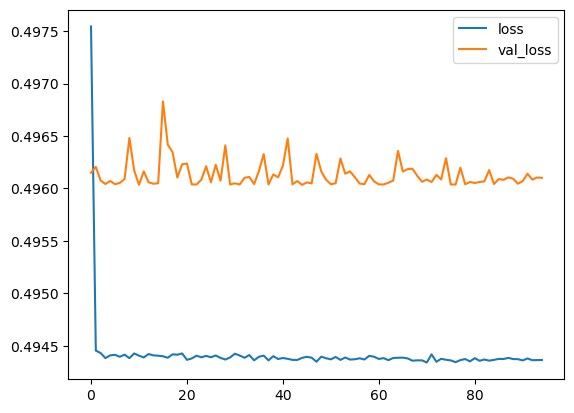

In [160]:
losses[['loss','val_loss']].plot()

In [155]:
predictions = model.predict(X_test_scaled)

4951/4951 ━━━━━━━━━━━━━━━━━━━━ 4s 737us/step


In [2]:
from sklearn.metrics import classification_report , confusion_matrix

In [161]:
print(np.unique(y_test))  # Should only contain [0, 1]
print(np.unique(predictions))

[0 1]
[0.79856384]


In [162]:
X = final_data.drop('loan_status',axis=1).values
y = final_data['loan_status'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)

In [163]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [164]:
model = Sequential()

# input layer
model.add(Dense(78,  activation='relu'))
model.add(Dropout(0.2))

# hidden layer
model.add(Dense(39, activation='relu'))
model.add(Dropout(0.2))

# hidden layer
model.add(Dense(19, activation='relu'))
model.add(Dropout(0.2))

# output layer
model.add(Dense(units=1,activation='sigmoid'))

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam')

In [165]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=25,
          batch_size=256,
          validation_data=(X_test, y_test), 
          )

Epoch 1/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.5323 - val_loss: 0.4945
Epoch 2/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4980 - val_loss: 0.4943
Epoch 3/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4977 - val_loss: 0.4944
Epoch 4/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4972 - val_loss: 0.4942
Epoch 5/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4986 - val_loss: 0.4945
Epoch 6/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4960 - val_loss: 0.4943
Epoch 7/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4963 - val_loss: 0.4943
Epoch 8/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4973 - val_loss: 0.4943
Epoch 9/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4952 - val_loss: 0.4942
Epoch 10/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4957 - val_loss: 0.4943
Epoch 11/25
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4932 - val_loss: 0.4945
Epoch 12/25
1238/1238 ━━━━━━━━

In [166]:
losses = pd.DataFrame(model.history.history)

<Axes: >

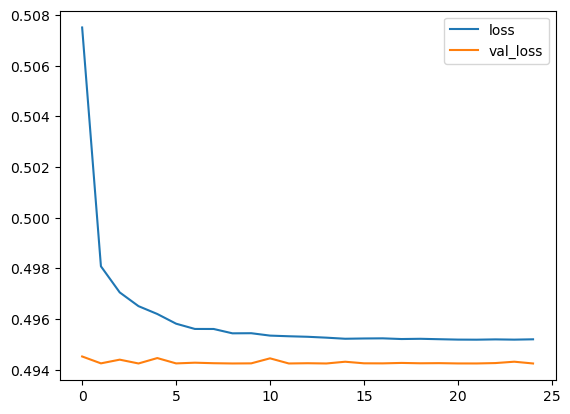

In [167]:
losses[['loss','val_loss']].plot()

In [169]:
predictions = model.predict(X_test)

2476/2476 ━━━━━━━━━━━━━━━━━━━━ 2s 766us/step


In [178]:
class_predictions = (predictions > 0.5).astype(int)
y_test_val = (y_test > 0.5).astype(int)
y_test_val

array([1, 1, 1, ..., 1, 1, 1])

In [187]:
# print(classification_report(y_test_val,predictions))

In [185]:
from sklearn.metrics import accuracy_score

In [186]:
accuracy_score(y_test_val,class_predictions)

0.8043961316061915